In [9]:
import numpy as np
import pandas as pd
from scipy.optimize import root
from scipy.special import kv

# ==========================================================
# FILE INPUT
# ==========================================================
file_linee = "Tab_completa_revisione.csv"
file_transizioni = "dati.asc"
file_mcmc = "risultati_MCMC.csv"

# ==========================================================
# COSTANTI ADAF
# ==========================================================
ALFA = 0.3
RMIN = 3.0
RMAX = 1000.0
DELTA = 0.0
C1 = 0.5
C3 = 0.3
TNORM = 1.68e-10

beta_default = 0.5

# ==========================================================
# FUNZIONI ADAF
# ==========================================================

def bessk(n, x):
    return kv(n, x)

def g(teta):
    return (
        (1.0 / bessk(2, 1.0 / teta))
        * (2.0 + 2.0 * teta + 1.0 / teta)
        * np.exp(-1.0 / teta)
    )

def temperat(y, mdot, m, beta):

    ff = y[2]**2
    xm = 1e3 * y[1]**2
    teta = y[0]**2

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm

    q1 = 1.2e4 * g(teta) * ALFA**(-2) * C1**(-2) * C3 * beta * m * mdot**2 / RMIN
    q2 = DELTA * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN
    q = q1 + q2

    nup = s1 * s2 * m**(-0.5) * mdot**0.5 * (teta / TNORM)**2 * RMIN**(-5/4)

    psinc = (
        53.0 * (xm / 1000.0)**3
        * (teta / (1e9 * TNORM))**7
        * m**0.5 * mdot**1.5
    )

    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    graffa = ((6.2e7 * (teta / (1e9 * TNORM))) / (nup * 1e-12))**(1 - alfac) - 1
    pcomp = (psinc / 0.71) / (1 - alfac) * graffa

    if teta < 1:
        f = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
    else:
        f = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

    pbrems = 4.78 * ALFA**(-2) * C1**(-2) * np.log(RMAX/RMIN) * f * m * mdot**2

    f1 = q - psinc - pcomp - pbrems
    f2 = (1 - ff) * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN - q

    vv = xm**(1/3)

    f3 = (
        vv + 1.852*np.log(vv)
        - 10.36
        - 0.26*np.log(m*mdot)
        + 0.26*np.log(teta**3 * bessk(2, 1/teta))
    )

    return [f1, f3, f2]


def spectrum(te, f, xm, m, mdot, beta):

    numin = 1e10
    numax = 1e21
    num = 100

    lnu = np.linspace(np.log10(numin), np.log10(numax), num)
    nu = 10**lnu

    teta = TNORM * te

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm
    s3 = 1.05e-24

    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    lnup = np.log10(s1 * s2 * m**(-0.5) * mdot**0.5 * te**2 * RMIN**(-5/4))
    lnucmax = np.log10(te) + 10.796

    llsinc = (
        3*np.log10(s1*s2)
        + np.log10(s3)
        - (7/4)*np.log10(RMIN)
        + np.log10(m**0.5 * mdot**1.5)
        + 7*np.log10(te)
    )

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    for i in range(num):

        if lnu[i] < lnup:
            lls[i] = (
                np.log10(s3)
                + (8/5)*np.log10(s1*s2)
                + np.log10(m**(6/5) * mdot**(4/5))
                + (21/5)*np.log10(te)
                + (2/5)*lnu[i]
            )
        else:
            lls[i] = -np.inf

        if lnu[i] > lnup:
            base = llsinc + (alfac - 1)*lnup - alfac*lnu[i]
            cutoff = -(10**(lnu[i] - lnucmax)) / np.log(10)
            llc[i] = base + cutoff
        else:
            llc[i] = -np.inf

        if teta < 1:
            fb = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
        else:
            fb = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

        base_b = (
            24.36
            - 2*np.log10(ALFA*C1)
            + np.log10(np.log(RMAX/RMIN) * fb)
            - np.log10(te)
            + np.log10(m * mdot**2)
        )

        cutoff_b = -(4.8e-11 * nu[i] / te) / np.log(10)
        llb[i] = base_b + cutoff_b

    comp_sync = np.where(np.isfinite(lls), 10**lls, 0.0)
    comp_comp = np.where(np.isfinite(llc), 10**llc, 0.0)
    comp_brems = np.where(np.isfinite(llb), 10**llb, 0.0)

    flux = comp_sync + comp_comp + comp_brems

    log_nuLnu = lnu + np.log10(flux)

    return lnu, log_nuLnu


def specdata(m, mdot, beta):

    y0 = [0.5, 1.0, 0.99]

    sol = root(
        temperat,
        y0,
        args=(mdot, m, beta),
        tol=1e-10
    )

    if not sol.success:
        raise RuntimeError(f"Soluzione ADAF non converge per m={m}, mdot={mdot}, beta={beta}")

    y = sol.x

    teta = y[0]**2
    te = teta / TNORM
    xm = 1e3 * y[1]**2
    f = y[2]**2

    lnu, log_nuLnu = spectrum(
        te=te,
        f=f,
        xm=xm,
        m=m,
        mdot=mdot,
        beta=beta
    )

    return lnu, log_nuLnu


def costruisci_spettro_adaf(m, mdot, beta):

    lnu, log_nuLnu = specdata(
        m=m,
        mdot=mdot,
        beta=beta
    )

    nu = 10**lnu
    nuLnu = 10**log_nuLnu
    Lnu = nuLnu / nu

    return nu, Lnu


# ==========================================================
# FUNZIONI DI SUPPORTO
# ==========================================================

def trova_colonna(df, possibili_nomi, obbligatoria=True):
    for nome in possibili_nomi:
        if nome in df.columns:
            return nome
    if obbligatoria:
        raise ValueError(f"Non trovo nessuna di queste colonne: {possibili_nomi}")
    return None


def leggi_transizioni(file_transizioni):
    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=("U50", float, float),
        unpack=True
    )

    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list
    })


def estrai_linee_osservate(row, norm_columns):
    risultati = []

    for col in norm_columns:
        valore = row[col]

        if pd.isna(valore) or valore <= 0:
            continue

        line_name = col.replace("_norm", "")
        L_line = valore * 1e42

        risultati.append({
            "line_name": line_name,
            "L_line": L_line
        })

    return pd.DataFrame(risultati)


def calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=None):

    risultati = []

    if nu_max is None:
        nu_max = np.max(nu)

    for _, row in df_trans.iterrows():

        line_name = row["line_name"]
        E_ion = row["E_ion"]
        nu_ion = row["nu_ion"]

        if nu_ion >= nu_max:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max)

            if np.sum(mask) < 2:
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])

        risultati.append({
            "line_name": line_name,
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "L_ion": L_ion
        })

    return pd.DataFrame(risultati)


def analizza_blazar_ADAF(row, df_trans, norm_columns):

    nome_blazar = row["label"]
    m = row["m_median_Msun"]
    mdot = row["mdot_median"]
    beta = beta_default

    try:
        nu, Lnu = costruisci_spettro_adaf(
            m=m,
            mdot=mdot,
            beta=beta
        )
    except RuntimeError as e:
        print(f"Attenzione: salto {nome_blazar}. Motivo: {e}")
        return pd.DataFrame()

    df_lion = calcola_lion_per_transizioni(
        nu=nu,
        Lnu=Lnu,
        df_trans=df_trans,
        nu_max=np.max(nu)
    )

    df_linee = estrai_linee_osservate(
        row=row,
        norm_columns=norm_columns
    )

    if df_linee.empty:
        return pd.DataFrame()

    df_conf = df_linee.merge(
        df_lion,
        on="line_name",
        how="left"
    )

    df_conf["covering_factor"] = df_conf["L_line"] / df_conf["L_ion"]

    df_conf.loc[
        (df_conf["L_ion"].isna()) | (df_conf["L_ion"] <= 0),
        "covering_factor"
    ] = np.nan

    df_conf["label"] = nome_blazar

    return df_conf[["label", "line_name","L_ion", "covering_factor"]]


# ==========================================================
# LETTURA FILE
# ==========================================================

df_tab = pd.read_csv(file_linee)
df_trans = leggi_transizioni(file_transizioni)
df_mcmc = pd.read_csv(file_mcmc)

col_name_tab = trova_colonna(
    df_tab,
    ["label", "file_name", "name", "nome", "blazar"]
)

df_tab = df_tab.rename(columns={col_name_tab: "label_originale"}).copy()
df_mcmc = df_mcmc.rename(columns={"Blazar": "label"}).copy()

# ==========================================================
# MERGE ROBUSTO DEI NOMI
# ==========================================================

df_tab["label_originale"] = df_tab["label_originale"].astype(str).str.strip()
df_mcmc["label"] = df_mcmc["label"].astype(str).str.strip()

# Esempi:
# J0021.6-6835 -> J0021
# J152422.56   -> J152422
df_tab["label"] = df_tab["label_originale"].str.extract(r"(J\d+)", expand=False)
df_mcmc["label"] = df_mcmc["label"].str.extract(r"(J\d+)", expand=False)

norm_columns = [col for col in df_tab.columns if col.endswith("_norm")]

df_all = df_tab.merge(
    df_mcmc[["label", "m_median_Msun", "mdot_median"]],
    on="label",
    how="inner"
)

if len(df_all) == 0:
    raise ValueError("Il merge non ha trovato blazar in comune.")


# ==========================================================
# CALCOLO CF ADAF PER TUTTI I BLAZAR
# ==========================================================

tutti_risultati = []

for i in range(len(df_all)):

    row = df_all.iloc[i]

    df_conf = analizza_blazar_ADAF(
        row=row,
        df_trans=df_trans,
        norm_columns=norm_columns
    )

    if not df_conf.empty:
        tutti_risultati.append(df_conf)

if len(tutti_risultati) == 0:
    raise ValueError("Nessun covering factor ADAF calcolato.")

df_cf_ADAF_mcmc = pd.concat(
    tutti_risultati,
    ignore_index=True
)


# ==========================================================
# TABELLA FINALE: BLAZAR + CF PER LINEA + MEDIA
# ==========================================================

tabella_finale_ADAF = df_cf_ADAF_mcmc.pivot_table(
    index="label",
    columns="line_name",
    values="covering_factor",
    aggfunc="first"
)

tabella_finale_ADAF["Cf_mean"] = tabella_finale_ADAF.mean(
    axis=1,
    skipna=True
)

ordine_linee = ["CIII", "CIV", "MgII", "Ha", "Hb", "Hg", "Hd"]
colonne_presenti = [
    c for c in ordine_linee
    if c in tabella_finale_ADAF.columns
]

tabella_finale_ADAF = tabella_finale_ADAF[
    colonne_presenti + ["Cf_mean"]
]

tabella_finale_ADAF = tabella_finale_ADAF.reset_index()

# ==========================================================
# STAMPA SOLO TABELLA FINALE
# ==========================================================

display(tabella_finale_ADAF)


Attenzione: salto J0508. Motivo: Soluzione ADAF non converge per m=620800.0, mdot=12.6, beta=0.5


line_name,label,CIII,CIV,MgII,Ha,Hb,Hg,Hd,Cf_mean
0,J0021,NaN,NaN,NaN,NaN,0.042646,0.012124,0.008721,0.021164
1,J0050,NaN,NaN,NaN,0.195889,0.040300,0.033166,0.006055,0.068852
2,J0059,NaN,NaN,1.770543,NaN,NaN,1.413357,0.632597,1.272166
3,J0133,NaN,NaN,0.557016,NaN,NaN,NaN,0.139207,0.348112
4,J0922,NaN,NaN,0.101261,NaN,0.010682,0.005442,0.014115,0.032875
5,J1123,NaN,NaN,NaN,0.021300,0.041802,0.016781,0.005680,0.021391
6,J1329,NaN,NaN,0.035402,NaN,NaN,0.007724,0.026385,0.023170
7,J152422,0.016482,NaN,0.036401,NaN,NaN,NaN,0.041611,0.031498
8,J170108,0.028831,0.006068,0.012410,NaN,NaN,NaN,NaN,0.015769
9,J1745,NaN,NaN,NaN,0.045646,0.013978,NaN,NaN,0.029812


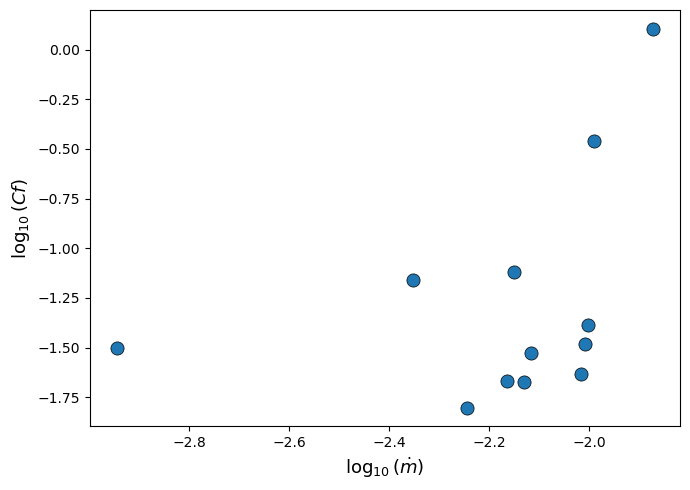

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# merge Cf medio + mdot
# ============================================

df_plot = tabella_finale_ADAF.merge(
    df_all[["label", "mdot_median"]],
    on="label",
    how="left"
)

df_plot = df_plot[
    df_plot["Cf_mean"].notna() &
    (df_plot["Cf_mean"] > 0) &
    df_plot["mdot_median"].notna() &
    (df_plot["mdot_median"] > 0)
].copy()

# ============================================
# log10
# ============================================

df_plot["log_mdot"] = np.log10(
    df_plot["mdot_median"]
)

df_plot["log_cf"] = np.log10(
    df_plot["Cf_mean"]
)

# ============================================
# grafico
# ============================================

plt.figure(figsize=(7,5))

plt.scatter(
    df_plot["log_mdot"],
    df_plot["log_cf"],
    s=90,
    edgecolors="black",
    linewidth=0.5
)
plt.xlabel(
    r'$\log_{10}(\dot m)$',
    fontsize=13
)

plt.ylabel(
    r'$\log_{10}(Cf)$',
    fontsize=13
)
plt.tight_layout()
plt.show()

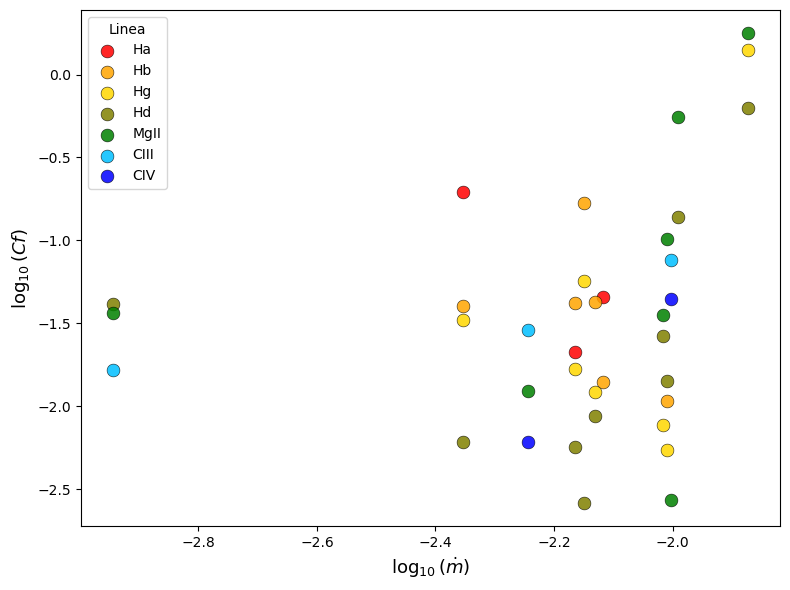

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ===========================================
# merge covering factor singoli + mdot
# ===========================================

df_plot = df_cf_ADAF_mcmc.merge(
    df_all[["label", "mdot_median"]],
    on="label",
    how="left"
)

df_plot["covering_factor"] = pd.to_numeric(
    df_plot["covering_factor"],
    errors="coerce"
)

df_plot = df_plot[
    df_plot["covering_factor"].notna() &
    (df_plot["covering_factor"] > 0) &
    df_plot["mdot_median"].notna() &
    (df_plot["mdot_median"] > 0)
].copy()

# ===========================================
# log10
# ===========================================

df_plot["log_cf"] = np.log10(
    df_plot["covering_factor"]
)

df_plot["log_mdot"] = np.log10(
    df_plot["mdot_median"]
)

# ===========================================
# colori linee
# ===========================================

color_map_linea = {
    "Ha": "red",
    "Hb": "orange",
    "Hg": "gold",
    "Hd": "olive",
    "MgII": "green",
    "CIII": "deepskyblue",
    "CIV": "blue"
}

# ===========================================
# grafico
# ===========================================

plt.figure(figsize=(8,6))

for linea in color_map_linea:

    df_l = df_plot[
        df_plot["line_name"] == linea
    ]

    if len(df_l) == 0:
        continue

    plt.scatter(
        df_l["log_mdot"],
        df_l["log_cf"],
        color=color_map_linea[linea],
        label=linea,
        s=85,
        edgecolors="black",
        linewidth=0.4,
        alpha=0.85
    )

plt.xlabel(
    r'$\log_{10}(\dot m)$',
    fontsize=13
)

plt.ylabel(
    r'$\log_{10}(Cf)$',
    fontsize=13
)


plt.legend(
    title="Linea",
    fontsize=10
)

plt.tight_layout()
plt.show()

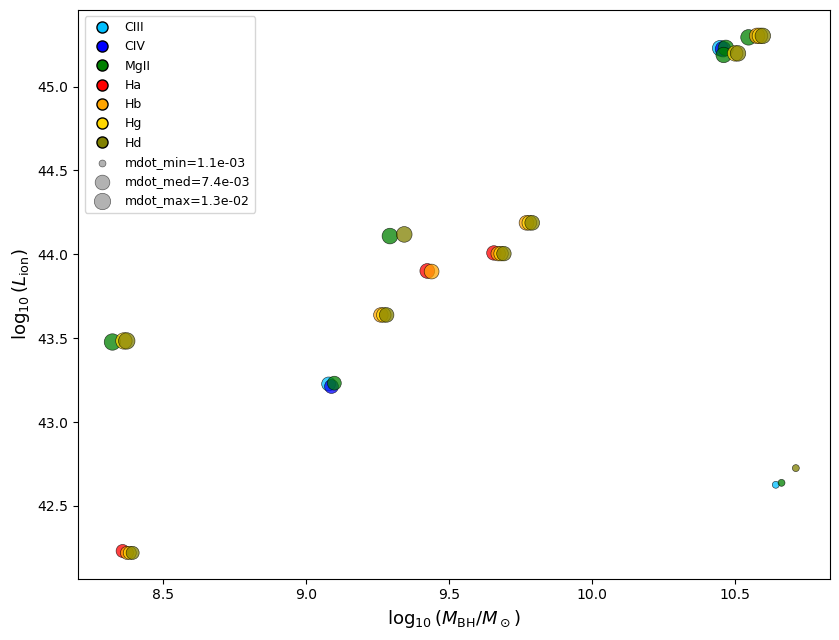

In [20]:
# ==================================================
# PREPARAZIONE LOG
# ==================================================

df_plot["logM"] = np.log10(
    df_plot["m_median_Msun"]
)

df_plot["logLion"] = np.log10(
    df_plot["L_ion"]
)

# ==================================================
# GRAFICO
# ==================================================
offset_linea = {
    "CIII": -0.035,
    "CIV": -0.025,
    "MgII": -0.015,
    "Ha": 0.000,
    "Hb": 0.015,
    "Hg": 0.025,
    "Hd": 0.035
}

fig, ax = plt.subplots(figsize=(8.5, 6.5))


for linea in linee_presenti:

    df_l = df_plot[
        df_plot["line_name"] == linea
    ]

    ax.scatter(
        df_l["logM"] + offset_linea.get(linea, 0),
        df_l["logLion"],
        s=df_l["size"],
        color=color_map_linea[linea],
        alpha=0.75,
        edgecolors="black",
        linewidth=0.45
    )

# ==================================================
# ASSI
# ==================================================

ax.set_xlabel(
    r"$\log_{10}(M_{\rm BH}/M_\odot)$",
    fontsize=13
)

ax.set_ylabel(
    r"$\log_{10}(L_{\rm ion})$",
    fontsize=13
)

# ==================================================
# LEGENDA COLORI LINEE
# ==================================================

legend_linee = [

    Line2D(
        [0],[0],
        marker='o',
        color='w',
        markerfacecolor=color_map_linea[linea],
        markeredgecolor='black',
        markersize=8,
        linestyle='None',
        label=linea
    )

    for linea in linee_presenti
]

# ==================================================
# mdot legenda
# ==================================================

mdot_min = df_plot["mdot_median"].min()
mdot_med = df_plot["mdot_median"].median()
mdot_max = df_plot["mdot_median"].max()

legend_mdot = []

for nome, valore in zip(

    ["mdot_min","mdot_med","mdot_max"],

    [mdot_min,mdot_med,mdot_max]

):

    size_val = (
        s_min
        +
        (s_max-s_min)
        *
        (
            (np.log10(valore)-log_mdot_min)
            /
            (log_mdot_max-log_mdot_min)
        )
    )

    legend_mdot.append(

        plt.scatter(
            [],
            [],
            s=size_val,
            color='gray',
            edgecolors='black',
            linewidth=0.45,
            alpha=0.6,
            label=rf"{nome}={valore:.1e}"
        )

    )

# ==================================================
# LEGENDA UNICA
# ==================================================

legend_totale = (
    legend_linee
    +
    legend_mdot
)

ax.legend(
    handles=legend_totale,
    loc="upper left",
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

In [19]:
print("Numero punti nel plot:", len(df_plot))
print(df_plot["line_name"].value_counts())
print(df_plot[["label", "line_name", "L_ion", "m_median_Msun", "mdot_median"]])

Numero punti nel plot: 37
line_name
Hd      9
MgII    7
Hg      7
Hb      6
Ha      3
CIII    3
CIV     2
Name: count, dtype: int64
      label line_name         L_ion  m_median_Msun  mdot_median
0     J1745        Ha  7.956350e+43   2.657000e+09     0.007629
1     J1745        Hb  7.891191e+43   2.657000e+09     0.007629
2     J0021        Hb  1.540420e+44   5.700000e+09     0.007394
3     J0021        Hg  1.540420e+44   5.700000e+09     0.007394
4     J0021        Hd  1.540420e+44   5.700000e+09     0.007394
5     J0050        Ha  1.702657e+42   2.291000e+08     0.004436
6     J0050        Hb  1.659209e+42   2.291000e+08     0.004436
7     J0050        Hg  1.659209e+42   2.291000e+08     0.004436
8     J0050        Hd  1.659209e+42   2.291000e+08     0.004436
9     J0922      MgII  1.964762e+45   3.643000e+10     0.009795
10    J0922        Hb  2.005923e+45   3.643000e+10     0.009795
11    J0922        Hg  2.005923e+45   3.643000e+10     0.009795
12    J0922        Hd  2.005923e+45 